# Problem statement

## Titanic Survival Prediction System

### Problem Statement

The objective of this project is to predict whether a passenger survived the Titanic disaster based on passenger information such as age, gender, passenger class, fare, family size, and embarkation point.

The project follows a complete machine learning workflow including data understanding, exploratory data analysis, feature engineering, model training, evaluation, model selection, and deployment through a Streamlit application.

# Import libraries

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Load dataset

In [6]:
df = sns.load_dataset("titanic")

# Dataset overview

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.shape

(891, 15)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
725,0,3,male,20.0,0,0,8.6625,S,Third,man,True,NaN,Southampton,no,True
326,0,3,male,61.0,0,0,6.2375,S,Third,man,True,NaN,Southampton,no,True
101,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
814,0,3,male,30.5,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
171,0,3,male,4.0,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False


Create a markdown table.

| Feature | Description |
|---------|-------------|
|survived | Target Variable |
| pclass | Passenger Class |
| sex | Gender |
| age | Age |
| sibsp	| Siblings/Spouses
| parch	| Parents/Children
| fare | Ticket Fare
| embarked | Port of Embarkation
| class | Travel Class
| who | Man/Woman/Child
| alone	| Traveling Alone

# EDA

### Exploratory Data Analysis (EDA)

The objective of EDA is to understand the dataset, identify patterns, discover relationships between features and the target variable, and gain insights that can improve model performance.

1. Missing value analysis

In [12]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
alive            0
alone            0
dtype: int64

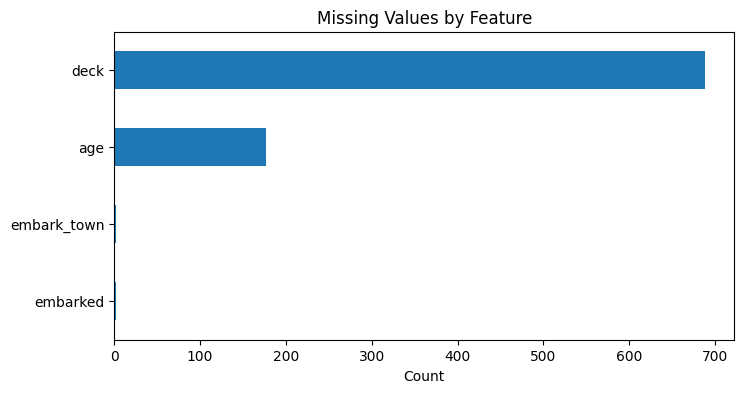

In [13]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(8,4))

missing_values.sort_values().plot(
    kind="barh"
)

plt.title("Missing Values by Feature")
plt.xlabel("Count")
plt.show()

### Observation

- Deck contains a large number of missing values.
- Age contains some missing values.
- Embarked contains very few missing values.
- Deck may need to be removed during preprocessing.

2. Target Variable Distribution

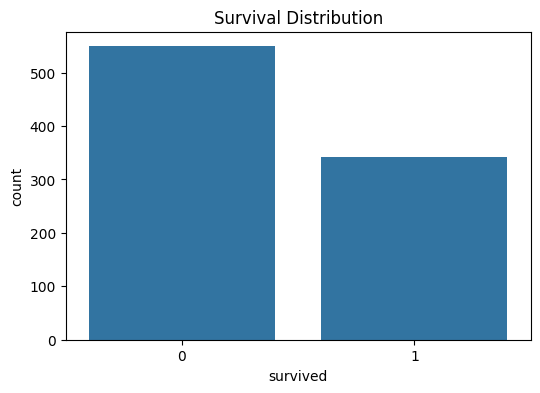

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="survived",
    data=df
)

plt.title("Survival Distribution")
plt.show()

In [16]:
(
    df["survived"]
    .value_counts(normalize=True)
    *100
).round(2)

survived
0    61.62
1    38.38
Name: proportion, dtype: float64

### Observation

- The dataset is reasonably balanced.
- More passengers died than survived.
- The target variable does not appear severely imbalanced.

3. Gender vs Survival

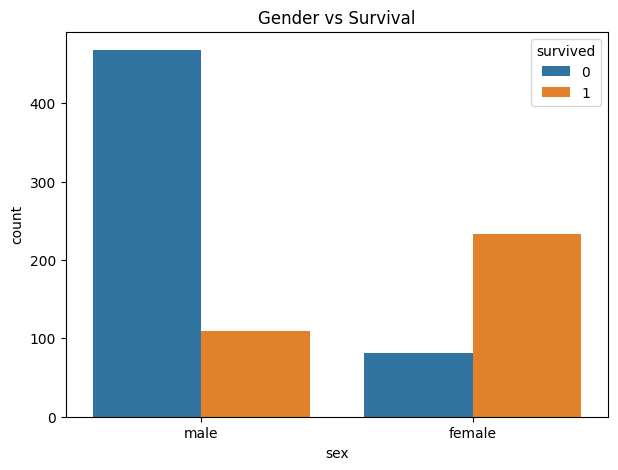

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="sex",
    hue="survived",
    data=df
)

plt.title("Gender vs Survival")
plt.show()

In [18]:
pd.crosstab(
    df["sex"],
    df["survived"],
    normalize="index"
) * 100

survived,0,1
sex,,
female,25.796178,74.203822
male,81.109185,18.890815


### Observation

- Female passengers had a significantly higher survival rate.
- Gender appears to be one of the strongest predictors of survival.

4. Passenger Class vs Survival

plt.figure(figsize=(7,5))

sns.countplot(
    x="pclass",
    hue="survived",
    data=df
)

plt.title("Passenger Class vs Survival")
plt.show()

In [20]:
pd.crosstab(
    df["pclass"],
    df["survived"],
    normalize="index"
) * 100

survived,0,1
pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


### Observation

- First-class passengers survived more often.
- Survival decreases as passenger class decreases.
- Passenger class is likely an important feature.

5. Age Distribution

# Data cleaning

# Feature Engineering

# Data preprocessing

# Train-test split

# Model building

# Model evaluation

# Hyperparameter tuning

# Save model